# Poverty Prediction and Euro Adoption Analysis in Eastern Europe

This notebook contains the empirical and computational analysis conducted for the Master's thesis examining the relationship between euro adoption, socio-economic indicators, and poverty dynamics in selected Eastern European countries between 2014 and 2025.

The analysis combines exploratory data analysis, supervised machine learning models, explainable artificial intelligence techniques, and longitudinal comparisons surrounding euro adoption. The objective is to evaluate both the predictive determinants of poverty and the broader socio-economic patterns associated with monetary integration within the European Union.

In [72]:
# Import core libraries
!pip install scikit-optimize
import os
import pandas as pd
import numpy as np
import shap

# Import statistical testing library

from scipy.stats import ttest_ind

# Visualization libraries

import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

# Import BayesSearchCV

from skopt import BayesSearchCV

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# Display settings

pd.set_option("display.max_columns", None)

# Ignore warnings

import warnings
warnings.filterwarnings("ignore")
# Folder where all generated figures will be saved
FIGURE_DIR = "/content/figures"
os.makedirs(FIGURE_DIR, exist_ok=True)
print(f"Figures will be saved in: {FIGURE_DIR}")


Figures will be saved in: /content/figures


## Dataset Loading

The dataset contains yearly socio-economic indicators for Bulgaria, Croatia, Lithuania, and Poland between 2014 and 2025. The variables include poverty rates, unemployment, inflation, GDP growth, inequality, housing burden, and financial vulnerability indicators.

In [73]:
# Load dataset

df = pd.read_csv("/content/master_dataset.csv")

# Display first rows

df.head()

,Country,Year,Poverty,Unemployment,Inflation,GDP_Growth,Gini,Housing_Burden,Unexpected_Expenses,EuroAdopted
0,Bulgaria,2014,21.8,12.4,-1.6,0.9,35.4,12.9,49.6,0
1,Bulgaria,2015,22.0,10.1,-1.1,3.4,37.0,14.8,53.4,0
2,Bulgaria,2016,22.9,8.6,-1.3,3.0,37.7,20.7,54.2,0
3,Bulgaria,2017,23.4,7.2,1.2,2.7,40.2,18.9,53.2,0
4,Bulgaria,2018,22.0,6.2,2.6,2.3,39.6,17.9,32.1,0


## Dataset Structure

The following section verifies the dimensions, variables, and structure of the dataset before conducting the analysis.

In [74]:
# Check dataset dimensions

print("Dataset shape:")
print(df.shape)

print("\nDataset columns:")
print(df.columns)

Dataset shape:
(48, 10)

Dataset columns:
Index(['Country', 'Year', 'Poverty', 'Unemployment', 'Inflation', 'GDP_Growth',
       'Gini', 'Housing_Burden', 'Unexpected_Expenses', 'EuroAdopted'],
      dtype='object')


## Descriptive Statistics

Summary statistics provide an overview of the socio-economic indicators included in the dataset.

In [75]:
# Generate descriptive statistics

df.describe()

,Year,Poverty,Unemployment,Inflation,GDP_Growth,Gini,Housing_Burden,Unexpected_Expenses,EuroAdopted
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,2019.500000,19.491667,6.893750,3.279167,3.202083,32.983333,7.756250,42.631250,0.291667
std,3.488583,2.978636,3.226777,4.293437,3.027638,4.671067,4.438224,10.435051,0.459340
min,2014.000000,13.200000,2.800000,-1.600000,-8.300000,24.900000,2.700000,22.500000,0.000000
25%,2016.750000,17.900000,4.750000,0.575000,2.650000,29.200000,4.875000,36.025000,0.000000
50%,2019.500000,20.000000,6.450000,2.350000,3.350000,32.900000,6.200000,42.400000,0.000000
75%,2022.250000,21.925000,8.000000,3.775000,4.450000,37.050000,8.800000,50.875000,1.000000
max,2025.000000,23.800000,17.300000,18.900000,12.600000,40.800000,20.700000,63.700000,1.000000


## Correlation Analysis

A correlation matrix is used to examine the relationships between poverty and the selected socio-economic variables.

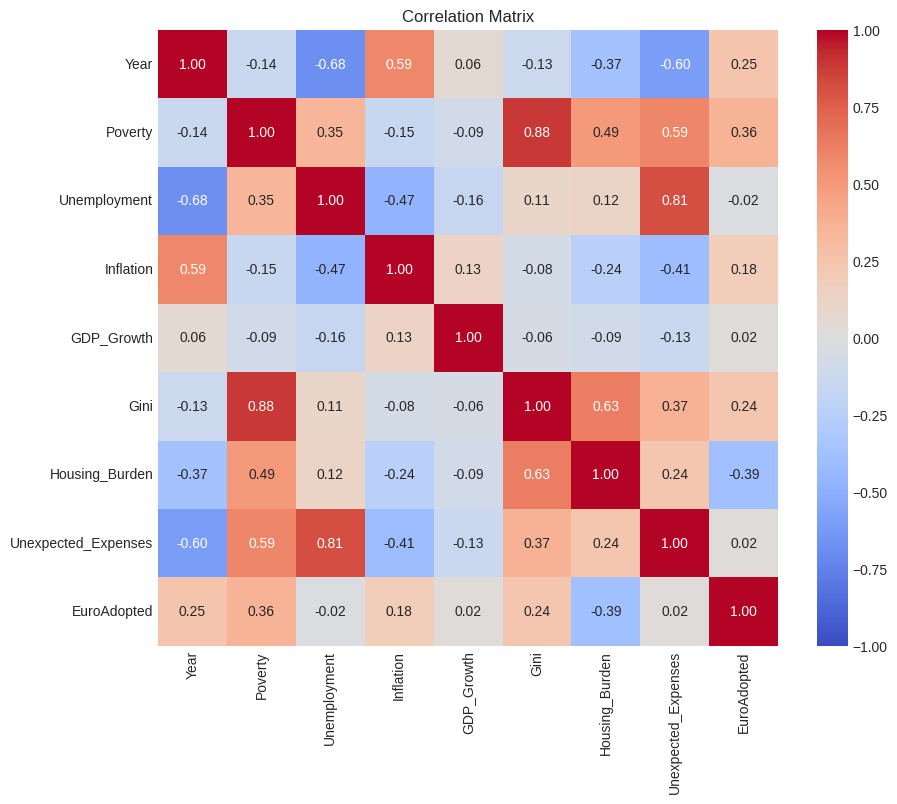

In [76]:
# Correlation matrix
corr = df.drop(columns=["Country"]).corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Correlation Matrix")

plt.savefig(
    os.path.join(FIGURE_DIR, "correlation_matrix.png"),
    bbox_inches="tight"
)

plt.show()

## Poverty Trends by Country

The following visualization illustrates the evolution of poverty rates across Bulgaria, Croatia, Lithuania, and Poland between 2014 and 2025. The figure provides a longitudinal overview of country-level trends and highlights differences between euro-adopting and non-adopting countries.

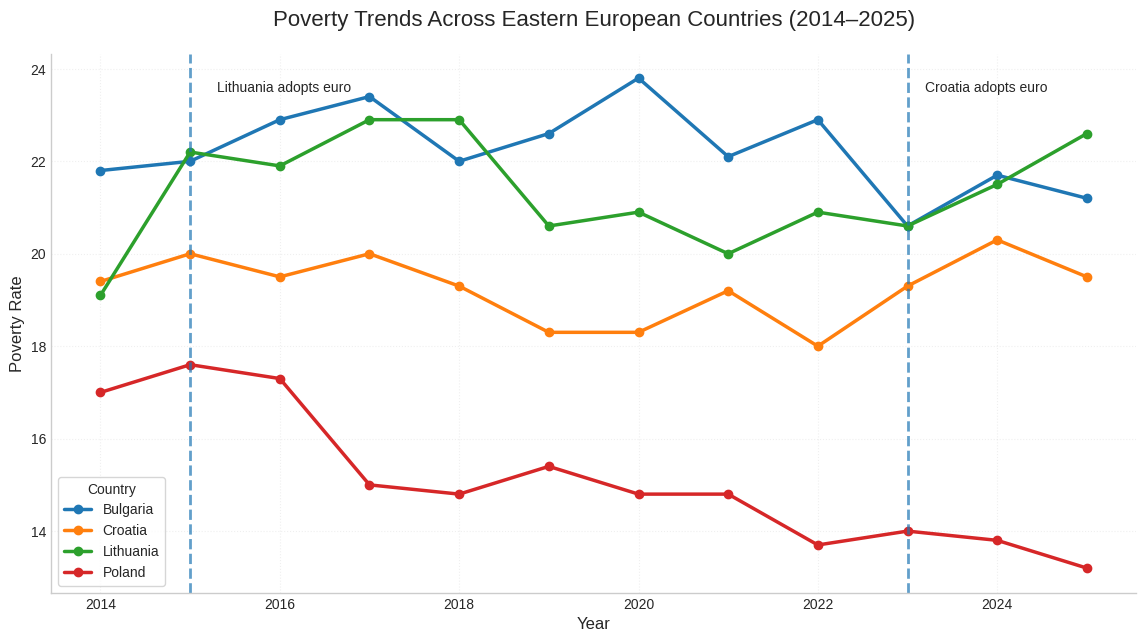

In [77]:
# Improved poverty trends visualization

plt.figure(figsize=(14,7))

# Plot each country separately

for country in df["Country"].unique():

    country_data = df[df["Country"] == country]

    plt.plot(
        country_data["Year"],
        country_data["Poverty"],
        marker="o",
        linewidth=2.5,
        markersize=6,
        label=country
    )

# Add euro adoption vertical lines

plt.axvline(
    x=2015,
    linestyle="--",
    linewidth=2,
    alpha=0.7
)

plt.axvline(
    x=2023,
    linestyle="--",
    linewidth=2,
    alpha=0.7
)

# Add annotations

plt.annotate(
    "Lithuania adopts euro",
    xy=(2015, 22),
    xytext=(2015.3, 23.5),
    fontsize=10
)

plt.annotate(
    "Croatia adopts euro",
    xy=(2023, 20),
    xytext=(2023.2, 23.5),
    fontsize=10
)

# Improve layout

plt.title(
    "Poverty Trends Across Eastern European Countries (2014–2025)",
    fontsize=16,
    pad=20
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Poverty Rate", fontsize=12)

# Add grid

plt.grid(
    alpha=0.3,
    linestyle=":"
)

# Improve legend

plt.legend(
    title="Country",
    frameon=True
)

# Remove top/right borders

sns.despine()

# Save figure

plt.savefig(
    os.path.join(FIGURE_DIR, "poverty_trends_by_country.png"),
    bbox_inches="tight"
)

plt.show()

## Feature Selection and Target Variable

The machine learning models use a set of socio-economic indicators as predictor variables to estimate poverty rates. Poverty is treated as the target variable, while unemployment, inflation, GDP growth, inequality, housing burden, financial vulnerability, and euro adoption status are used as explanatory variables.

In [78]:
# Define predictor variables

X = df[[
    "Unemployment",
    "Inflation",
    "GDP_Growth",
    "Gini",
    "Housing_Burden",
    "Unexpected_Expenses",
    "EuroAdopted"
]]

# Define target variable

y = df["Poverty"]

## Evolution of Socioeconomic Variables by Country

The following figures illustrate the evolution of all socioeconomic variables included in the analysis for each country between 2014 and 2025.

Each subplot represents a single country and displays the temporal development of the variables used in the machine learning models. The dashed vertical line indicates the chronological train-test split, where observations up to 2022 were used for training and observations from 2023 onward were reserved for testing and forecasting evaluation.

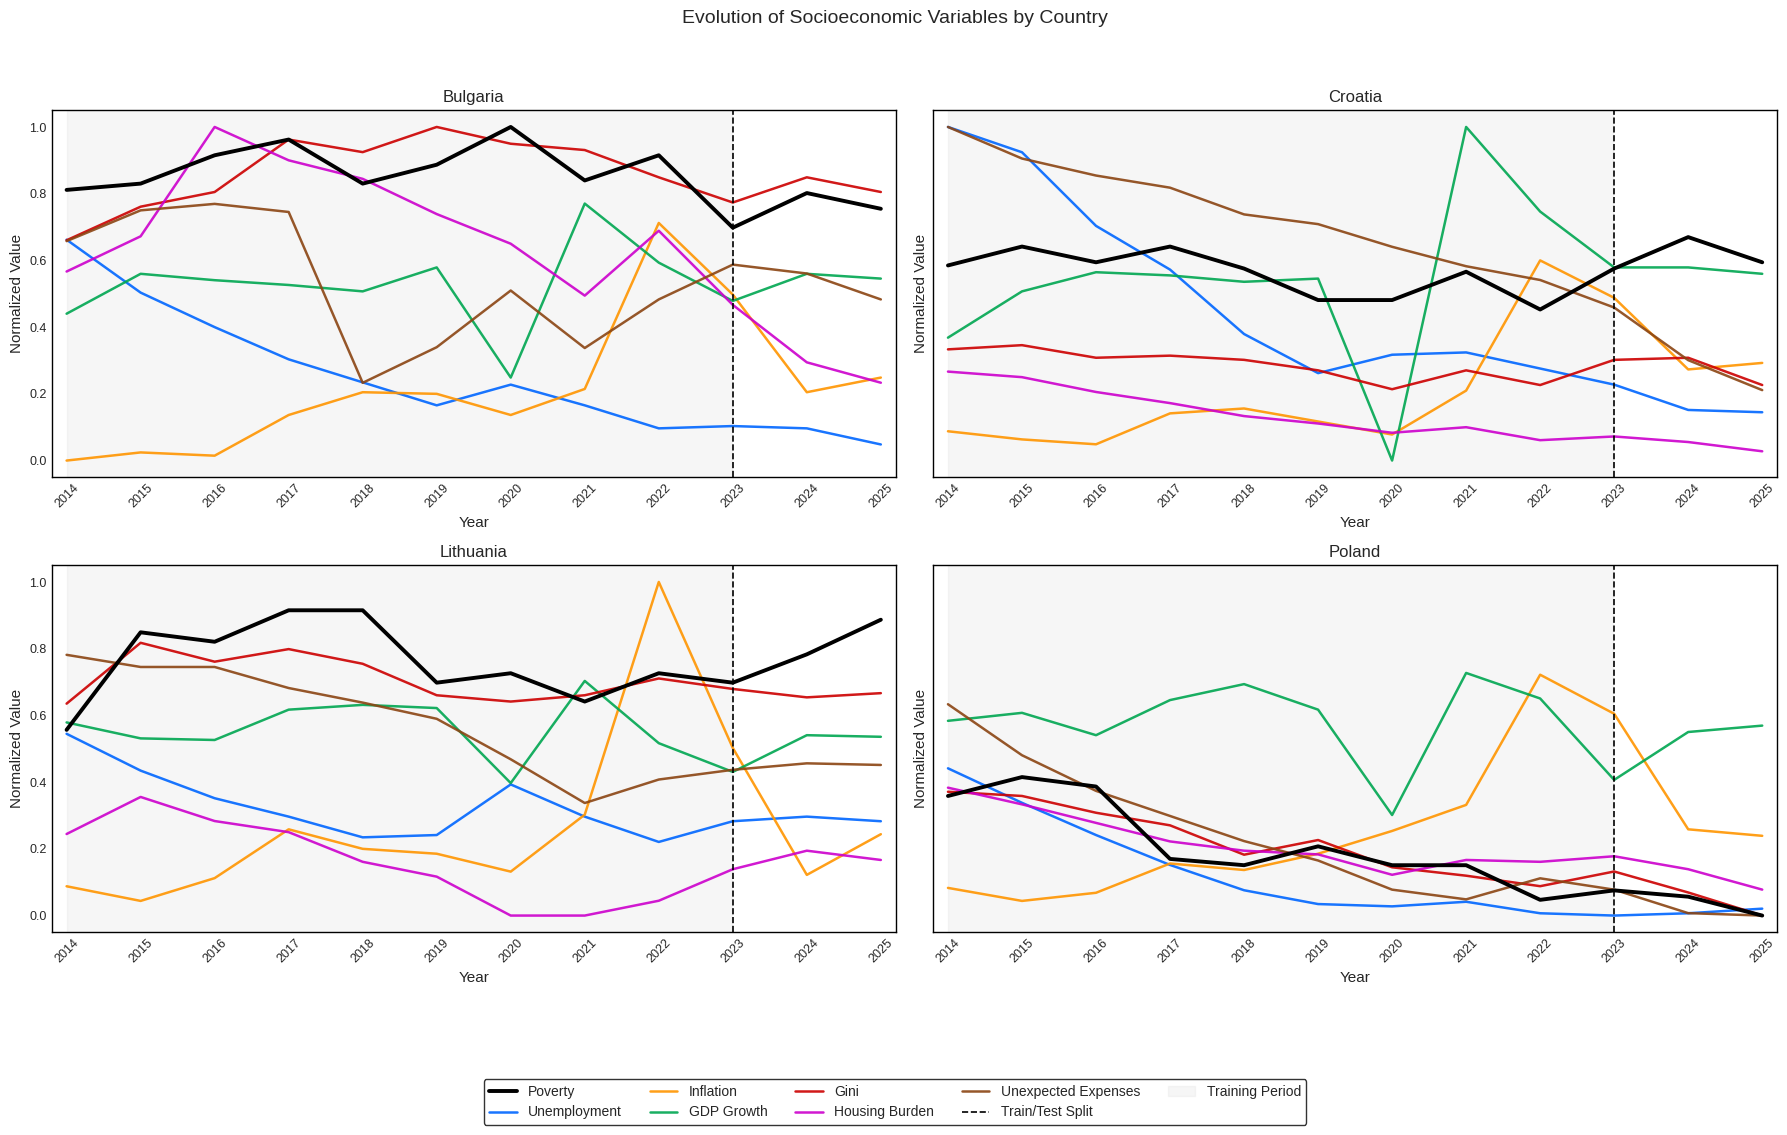

In [79]:
# Evolution of all socioeconomic variables by country
# Poverty emphasized as the target variable

variables = [
    "Poverty",
    "Unemployment",
    "Inflation",
    "GDP_Growth",
    "Gini",
    "Housing_Burden",
    "Unexpected_Expenses"
]

countries = df_sorted["Country"].unique()

normalized_df = df_sorted.copy()

# Normalize variables for comparability
for variable in variables:
    normalized_df[variable] = (
        normalized_df[variable] - normalized_df[variable].min()
    ) / (
        normalized_df[variable].max() - normalized_df[variable].min()
    )

variable_colors = {
    "Poverty": "#000000",
    "Unemployment": "#0066FF",
    "Inflation": "#FF9500",
    "GDP_Growth": "#00A651",
    "Gini": "#CC0000",
    "Housing_Burden": "#CC00CC",
    "Unexpected_Expenses": "#8B4513"
}

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 11),
    sharex=False,
    sharey=True
)

axes = axes.flatten()

for ax, country in zip(axes, countries):

    country_data = normalized_df[
        normalized_df["Country"] == country
    ].sort_values("Year")

    for variable in variables:

        # Emphasize target variable
        if variable == "Poverty":

            ax.plot(
                country_data["Year"],
                country_data[variable],
                linewidth=2.8,
                color=variable_colors[variable],
                label=variable.replace("_", " "),
                zorder=5
            )

        else:

            ax.plot(
                country_data["Year"],
                country_data[variable],
                linewidth=1.8,
                color=variable_colors[variable],
                alpha=0.9,
                label=variable.replace("_", " ")
            )

    # Train/test split
    ax.axvline(
        x=2023,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label="Train/Test Split"
    )

    # Training period shading
    ax.axvspan(
        2014,
        2022.99,
        color="lightgray",
        alpha=0.20,
        label="Training Period"
    )

    ax.set_title(country, fontsize=12)

    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Normalized Value", fontsize=11)

    # Show years on ALL charts
    ax.set_xticks(range(2014, 2026))

    ax.tick_params(
        axis="x",
        rotation=45,
        labelsize=9
    )

    ax.tick_params(
        axis="y",
        labelsize=9
    )

    ax.set_xlim(2013.8, 2025.2)
    ax.set_ylim(-0.05, 1.05)

    # Academic style
    ax.set_facecolor("white")
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()

unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="lower center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=5,
    frameon=True,
    edgecolor="black",
    fontsize=10
)

plt.suptitle(
    "Evolution of Socioeconomic Variables by Country",
    fontsize=14
)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "all_variables_evolution_by_country.png"
    ),
    dpi=400,
    bbox_inches="tight"
)

plt.show()

## Chronological Train-Test Split

To evaluate model generalisation on future observations, the dataset is divided chronologically rather than randomly. Observations from earlier years are used for training, while observations from later years are reserved for testing. This approach is more appropriate for time-dependent socio-economic data because it evaluates whether the models can predict later poverty outcomes using information from previous years.

In [80]:
# Create chronological train-test split

# Sort dataset by time first
df_sorted = df.sort_values(["Year", "Country"]).reset_index(drop=True)

# Use past years for training and future years for testing
train_df = df_sorted[df_sorted["Year"] <= 2022].copy()
test_df = df_sorted[df_sorted["Year"] >= 2023].copy()

# Define features and target
X_train = train_df[X.columns]
y_train = train_df["Poverty"]

X_test = test_df[X.columns]
y_test = test_df["Poverty"]

# Display split information
print("Training years:", train_df["Year"].min(), "-", train_df["Year"].max())
print("Testing years:", test_df["Year"].min(), "-", test_df["Year"].max())
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training years: 2014 - 2022
Testing years: 2023 - 2025
Training set shape: (36, 7)
Testing set shape: (12, 7)


## Feature Scaling

Feature scaling is applied before Linear Regression and Support Vector Regression to ensure that variables measured on different scales become comparable.

In [81]:
# Scale variables

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Linear Regression Model

Linear Regression is used as a baseline model to estimate the relationship between socio-economic indicators and poverty rates. Because the variables are standardized, the resulting coefficients can be compared directly across predictors.

In [82]:
# Train Linear Regression model

lr_model = LinearRegression()

lr_model.fit(
    X_train_scaled,
    y_train
)

# Generate predictions

pred_lr = lr_model.predict(X_test_scaled)

## Linear Regression Performance Evaluation

The following metrics evaluate the predictive performance of the Linear Regression model on the testing dataset.

In [83]:
# Evaluate Linear Regression model

lr_r2 = r2_score(y_test, pred_lr)

lr_mae = mean_absolute_error(y_test, pred_lr)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, pred_lr)
)

# Print results

print("Linear Regression Results")

print("R²:", round(lr_r2, 4))

print("MAE:", round(lr_mae, 4))

print("RMSE:", round(lr_rmse, 4))

Linear Regression Results
R²: 0.6593
MAE: 1.4702
RMSE: 1.8776


## Linear Regression Coefficients

Because all predictor variables were standardized before training, the regression coefficients can be interpreted comparatively. Larger absolute coefficient values indicate stronger relationships with poverty rates.

In [84]:
# Create coefficient dataframe

coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": lr_model.coef_
})

# Sort coefficients

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Variable,Coefficient
3,Gini,2.499265
5,Unexpected_Expenses,1.115895
1,Inflation,0.176331
0,Unemployment,-0.077848
2,GDP_Growth,-0.082411
6,EuroAdopted,-0.116157
4,Housing_Burden,-0.206852


## Linear Regression Coefficient Visualization

The following figure visualizes the relative influence of the standardized socio-economic variables in the Linear Regression model.

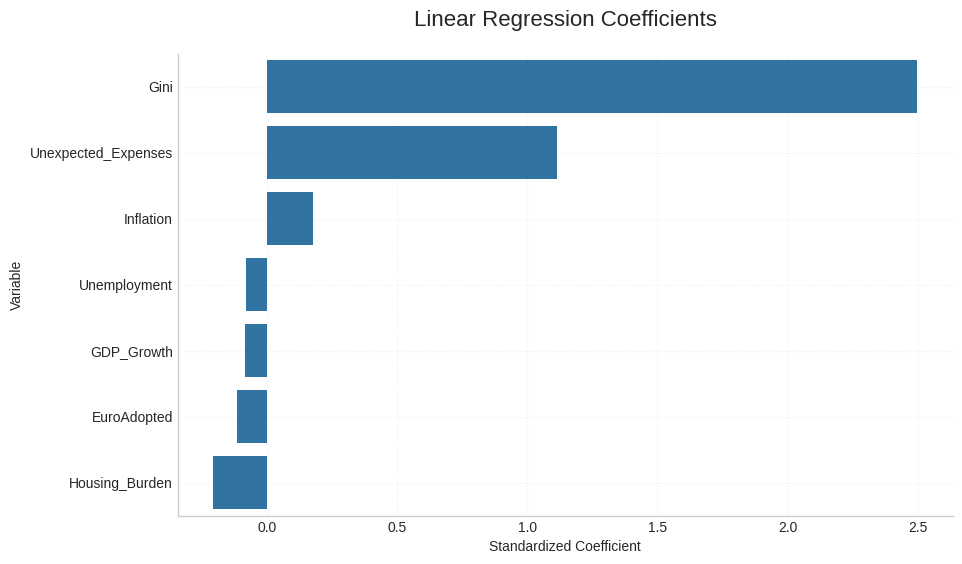

In [85]:
# Plot regression coefficients

plt.figure(figsize=(10,6))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Variable"
)

plt.title(
    "Linear Regression Coefficients",
    fontsize=16,
    pad=20
)

plt.xlabel("Standardized Coefficient")
plt.ylabel("Variable")

plt.grid(
    alpha=0.3,
    linestyle=":"
)

sns.despine()

plt.savefig(
    os.path.join(FIGURE_DIR, "linear_regression_coefficients.png"),
    bbox_inches="tight"
)

plt.show()

##Support Vector Regression Model (SVR)

Support Vector Regression (SVR) is implemented to capture potential non-linear relationships between socio-economic indicators and poverty rates. Because SVR is sensitive to feature scale, standardized predictor variables are used. The model is trained on observations from earlier years and evaluated on later unseen years using the chronological train-test split.

In [86]:
# Train Support Vector Regression model

svr_model = SVR(
    kernel="rbf"
)

svr_model.fit(
    X_train_scaled,
    y_train
)

# Generate predictions

pred_svr = svr_model.predict(X_test_scaled)

## Support Vector Regression Performance Evaluation

The following metrics evaluate the predictive performance of the Support Vector Regression model on the testing dataset.

In [87]:
# Evaluate Support Vector Regression model

svr_r2 = r2_score(y_test, pred_svr)

svr_mae = mean_absolute_error(y_test, pred_svr)

svr_rmse = np.sqrt(
    mean_squared_error(y_test, pred_svr)
)

# Print results

print("Support Vector Regression Results")

print("R²:", round(svr_r2, 4))

print("MAE:", round(svr_mae, 4))

print("RMSE:", round(svr_rmse, 4))

Support Vector Regression Results
R²: 0.7412
MAE: 1.3361
RMSE: 1.6365


## Optimized Support Vector Regression

Bayesian hyperparameter optimisation is applied to the Support Vector Regression model using time-series cross-validation. The optimisation process searches for parameter combinations that improve predictive performance while preserving chronological order in the training and validation process.

In [88]:
from skopt import BayesSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.svm import SVR
from skopt.space import Real, Categorical

# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=3)

# SVR search space
svr_param_space = {
    "kernel": Categorical(["rbf"]),
    "C": Real(0.1, 100, prior="log-uniform"),
    "gamma": Real(0.001, 10, prior="log-uniform"),
    "epsilon": Real(0.01, 1.0, prior="log-uniform")
}

# Bayesian optimisation for SVR
svr_search = BayesSearchCV(
    estimator=SVR(),
    search_spaces=svr_param_space,
    n_iter=30,
    scoring="r2",
    cv=tscv,
    n_jobs=-1
)

svr_search.fit(X_train_scaled, y_train)

best_svr_model = svr_search.best_estimator_
pred_svr_optimized = best_svr_model.predict(X_test_scaled)

svr_opt_r2 = r2_score(y_test, pred_svr_optimized)
svr_opt_mae = mean_absolute_error(y_test, pred_svr_optimized)
svr_opt_rmse = np.sqrt(mean_squared_error(y_test, pred_svr_optimized))

print("Optimized SVR Results")
print("Best parameters:", svr_search.best_params_)
print("R²:", round(svr_opt_r2, 4))
print("MAE:", round(svr_opt_mae, 4))
print("RMSE:", round(svr_opt_rmse, 4))

Optimized SVR Results
Best parameters: OrderedDict({'C': 57.31078376993879, 'epsilon': 0.11368498580952623, 'gamma': 0.003101405149471798, 'kernel': 'rbf'})
R²: 0.7547
MAE: 1.1752
RMSE: 1.5932


## Optimized Support Vector Regression Performance Evaluation

The optimized Support Vector Regression model is evaluated on the chronological testing dataset using R², MAE, and RMSE.

## Random Forest Regression Model

Random Forest Regression is implemented as a baseline ensemble model to capture potential non-linear relationships and interactions between socio-economic indicators and poverty rates. The model is trained on earlier years and evaluated on later unseen years using the chronological train-test split. No random train-test split is used.

In [89]:
# Train baseline Random Forest model

rf_model = RandomForestRegressor()

rf_model.fit(
    X_train,
    y_train
)

# Generate predictions on future test years

pred_rf = rf_model.predict(X_test)

## Random Forest Performance Evaluation

The following metrics evaluate the predictive performance of the baseline Random Forest Regression model on the chronological testing dataset.

In [90]:
# Evaluate baseline Random Forest model

rf_r2 = r2_score(y_test, pred_rf)

rf_mae = mean_absolute_error(y_test, pred_rf)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, pred_rf)
)

# Print results

print("Random Forest Results")
print("R²:", round(rf_r2, 4))
print("MAE:", round(rf_mae, 4))
print("RMSE:", round(rf_rmse, 4))

Random Forest Results
R²: 0.6377
MAE: 1.4025
RMSE: 1.9361


## Bayesian Hyperparameter Optimisation

After evaluating the baseline Random Forest model, Bayesian hyperparameter optimisation is applied using BayesSearchCV. The optimisation process searches for a stronger combination of Random Forest parameters while preserving chronological order through time-series cross-validation.

In [91]:
# Install scikit-optimize if needed

!pip install scikit-optimize

# Import Bayesian optimisation and time-series cross-validation

from skopt import BayesSearchCV
from sklearn.model_selection import TimeSeriesSplit

In [92]:
# Define parameter search space

param_space = {
    "n_estimators": (50, 300),
    "max_depth": (2, 20),
    "min_samples_split": (2, 10),
    "min_samples_leaf": (1, 5),
    "max_features": ["sqrt", "log2"]
}

In [93]:
# Define time-series cross-validation

tscv = TimeSeriesSplit(n_splits=3)

# Initialize Bayesian hyperparameter search

bayes_search = BayesSearchCV(
    estimator=RandomForestRegressor(),
    search_spaces=param_space,
    n_iter=20,
    scoring="r2",
    cv=tscv,
    n_jobs=-1
)

In [94]:
# Run hyperparameter optimisation on training data only

bayes_search.fit(
    X_train,
    y_train
)

# Display best results

print("Best R² score during time-series cross-validation:", round(bayes_search.best_score_, 4))
print("Best parameters:", bayes_search.best_params_)

Best R² score during time-series cross-validation: 0.676
Best parameters: OrderedDict({'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50})


## Optimized Random Forest Model

The best-performing Random Forest configuration obtained through Bayesian optimisation is used to train the optimized model. The final model is evaluated on the later chronological testing period.

In [95]:
# Retrieve best optimized Random Forest model

optimized_rf_model = bayes_search.best_estimator_

# Generate predictions on future test years

pred_rf_optimized = optimized_rf_model.predict(X_test)

In [96]:
# Evaluate optimized Random Forest model

rf_opt_r2 = r2_score(y_test, pred_rf_optimized)

rf_opt_mae = mean_absolute_error(y_test, pred_rf_optimized)

rf_opt_rmse = np.sqrt(
    mean_squared_error(y_test, pred_rf_optimized)
)

# Print results

print("Optimized Random Forest Results")
print("R²:", round(rf_opt_r2, 4))
print("MAE:", round(rf_opt_mae, 4))
print("RMSE:", round(rf_opt_rmse, 4))

Optimized Random Forest Results
R²: 0.7705
MAE: 1.2507
RMSE: 1.541


## Bayesian Optimisation Summary

The table below summarizes the Bayesian hyperparameter optimisation process for the optimized Support Vector Regression and Random Forest models. It reports the optimisation method, cross-validation strategy, number of iterations, parameter search space, selected best parameters, and final test-set performance.

In [97]:
# Bayesian optimisation summary table

bayesian_optimization_table = pd.DataFrame({
    "Model": [
        "Optimized Support Vector Regression",
        "Optimized Random Forest"
    ],
    "Optimisation Method": [
        "BayesSearchCV",
        "BayesSearchCV"
    ],
    "Cross-Validation": [
        "TimeSeriesSplit, 3 splits",
        "TimeSeriesSplit, 3 splits"
    ],
    "Iterations": [
        30,
        20
    ],
    "Scoring Metric": [
        "R²",
        "R²"
    ],
    "Parameters Tested": [
        "kernel = rbf; C = 0.1–100; gamma = 0.001–10; epsilon = 0.01–1.0",
        "n_estimators = 50–300; max_depth = 2–20; min_samples_split = 2–10; min_samples_leaf = 1–5; max_features = sqrt/log2"
    ],
    "Best Parameters": [
        svr_search.best_params_,
        bayes_search.best_params_
    ],
    "Test R²": [
        svr_opt_r2,
        rf_opt_r2
    ],
    "Test MAE": [
        svr_opt_mae,
        rf_opt_mae
    ],
    "Test RMSE": [
        svr_opt_rmse,
        rf_opt_rmse
    ]
})

bayesian_optimization_table = bayesian_optimization_table.round(4)

display(bayesian_optimization_table)

,Model,Optimisation Method,Cross-Validation,Iterations,Scoring Metric,Parameters Tested,Best Parameters,Test R²,Test MAE,Test RMSE
0,Optimized Support Vector Regression,BayesSearchCV,"TimeSeriesSplit, 3 splits",30,R²,kernel = rbf; C = 0.1–100; gamma = 0.001–10; e...,"{'C': 57.31078376993879, 'epsilon': 0.11368498...",0.7547,1.1752,1.5932
1,Optimized Random Forest,BayesSearchCV,"TimeSeriesSplit, 3 splits",20,R²,n_estimators = 50–300; max_depth = 2–20; min_s...,"{'max_depth': 20, 'max_features': 'sqrt', 'min...",0.7705,1.2507,1.5410


## Explainable Artificial Intelligence with SHAP

To improve model interpretability, SHAP (SHapley Additive exPlanations) values are used to explain the contribution of each socio-economic variable to the Random Forest predictions. SHAP provides a more detailed interpretation than traditional feature importance metrics by showing both the magnitude and direction of variable effects.

In [98]:
# Install SHAP

!pip install shap

## TreeExplainer Initialization

TreeExplainer is specifically designed for tree-based models such as Random Forest and is used to compute SHAP values for the optimized Random Forest model.

In [99]:
# Initialize TreeExplainer

explainer = shap.TreeExplainer(best_rf)

# Calculate SHAP values

shap_values = explainer.shap_values(X_test)

## SHAP Summary Plot

The SHAP summary plot visualizes the overall contribution of each variable to the model predictions. Variables appearing higher in the figure have greater overall importance, while color gradients indicate whether high or low variable values increase predicted poverty rates.

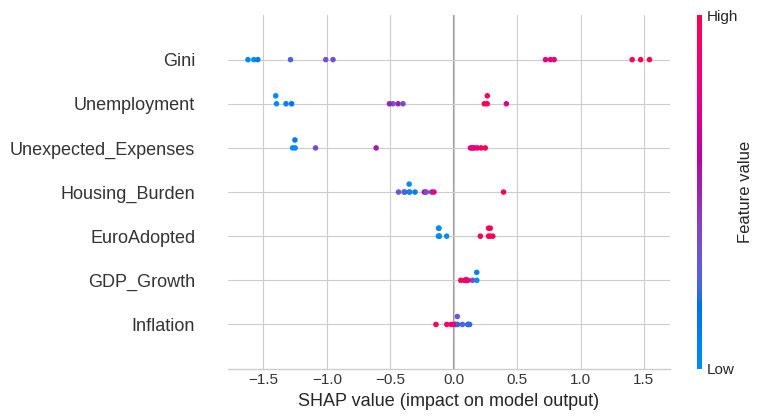

In [100]:
# SHAP summary beeswarm plot

shap.summary_plot(
    shap_values,
    X_test,
    max_display=7,
    show=False
)

plt.savefig(
    os.path.join(FIGURE_DIR, "shap_summary_beeswarm.png"),
    bbox_inches="tight"
)

plt.show()


## SHAP Interpretation

The SHAP summary plot provides a global interpretation of the optimized Random Forest model by illustrating the contribution of each socio-economic variable to the predicted poverty rates. Variables positioned higher in the figure exhibit greater overall importance within the model. The horizontal axis represents SHAP values, where positive values indicate an increase in predicted poverty rates and negative values indicate a decrease.

The results demonstrate that the Gini coefficient is the most influential predictor, followed by unemployment and the inability to cover unexpected expenses. Higher values of these variables are generally associated with increased predicted poverty levels. In contrast, variables such as GDP growth and inflation exhibit comparatively smaller overall contributions to the model predictions.

The color gradient further illustrates the relationship between feature magnitude and prediction direction. Red points correspond to higher feature values, while blue points represent lower values. The figure therefore highlights the importance of socio-economic inequality, labour market vulnerability, and financial insecurity in explaining poverty dynamics within the analysed Eastern European countries.

## Model Performance Comparison

To evaluate the effectiveness of the implemented machine learning approaches, the performance of all models was compared using Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R² score.

RMSE and MAE measure prediction error, where lower values indicate better model performance. The R² score measures the proportion of variance explained by the model, with higher values indicating stronger explanatory power.

The following table presents the performance results for the Baseline, KNN, Random Forest, and Support Vector Machine (SVM) models.

In [101]:
# Final model comparison table

comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Optimized Support Vector Regression",
        "Optimized Random Forest"
    ],

    "R²": [
        lr_r2,
        svr_opt_r2,
        rf_opt_r2
    ],

    "MAE": [
        lr_mae,
        svr_opt_mae,
        rf_opt_mae
    ],

    "RMSE": [
        lr_rmse,
        svr_opt_rmse,
        rf_opt_rmse
    ]
})

# Round values
comparison_df = comparison_df.round(4)

# Sort by RMSE (lower is better)
comparison_df = comparison_df.sort_values(by="RMSE")

# Reset index
comparison_df = comparison_df.reset_index(drop=True)

# Display comparison table
display(comparison_df)

,Model,R²,MAE,RMSE
0,Optimized Random Forest,0.7705,1.2507,1.5410
1,Optimized Support Vector Regression,0.7547,1.1752,1.5932
2,Linear Regression,0.6593,1.4702,1.8776


## Country-Level Forecasting Performance

The following figure visualizes model forecasting performance separately for each country. The vertical dashed line marks the chronological train-test split, where observations up to 2022 are used for training and observations from 2023 onward are used for testing.  

For each country, the actual poverty trend is compared against the predictions from Linear Regression, Optimized Support Vector Regression, and Optimized Random Forest during the testing period.

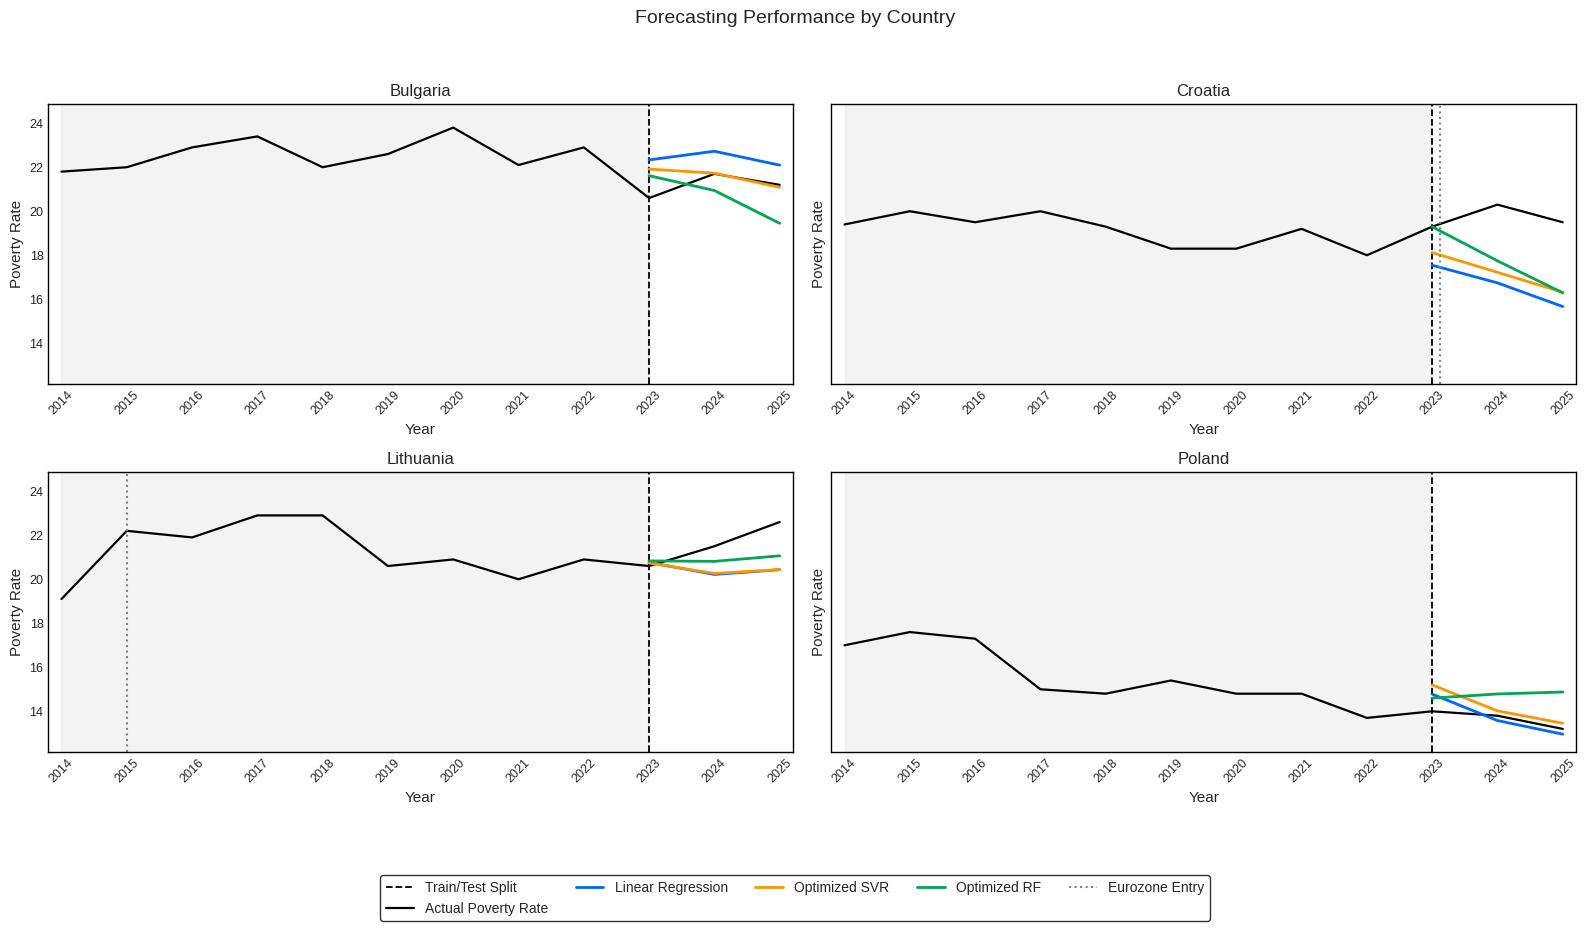

In [102]:
# Final country-level forecasting figure
# Clear train/test split and country-level forecasts

forecast_df = test_df[["Country", "Year", "Poverty"]].copy()

forecast_df["Linear Regression"] = pred_lr
forecast_df["Optimized SVR"] = pred_svr_optimized
forecast_df["Optimized Random Forest"] = pred_rf_optimized

countries = df_sorted["Country"].unique()

# Eurozone entry years
euro_entry_years = {
    "Croatia": 2023,
    "Lithuania": 2015,
    "Bulgaria": None,
    "Poland": None
}

# Bright model colors
model_colors = {
    "Linear Regression": "#0066FF",
    "Optimized SVR": "#FF9500",
    "Optimized RF": "#00A651"
}

# Standardized y-axis across all countries
y_min = df_sorted["Poverty"].min()
y_max = df_sorted["Poverty"].max()
y_padding = (y_max - y_min) * 0.10

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 9),
    sharex=False,
    sharey=True
)

axes = axes.flatten()

for ax, country in zip(axes, countries):

    full_country = df_sorted[
        df_sorted["Country"] == country
    ].sort_values("Year")

    test_country = forecast_df[
        forecast_df["Country"] == country
    ].sort_values("Year")

    # Training/testing background shading
    ax.axvspan(
        2014,
        2022.99,
        color="lightgray",
        alpha=0.25
    )

    # Train/test split line
    ax.axvline(
        x=2023,
        color="black",
        linestyle="--",
        linewidth=1.3,
        label="Train/Test Split"
    )

    # Actual poverty rate
    ax.plot(
        full_country["Year"],
        full_country["Poverty"],
        color="black",
        linewidth=1.6,
        label="Actual Poverty Rate"
    )

    # Linear Regression predictions
    ax.plot(
        test_country["Year"],
        test_country["Linear Regression"],
        color=model_colors["Linear Regression"],
        linewidth=2,
        label="Linear Regression"
    )

    # Optimized SVR predictions
    ax.plot(
        test_country["Year"],
        test_country["Optimized SVR"],
        color=model_colors["Optimized SVR"],
        linewidth=2,
        label="Optimized SVR"
    )

    # Optimized RF predictions
    ax.plot(
        test_country["Year"],
        test_country["Optimized Random Forest"],
        color=model_colors["Optimized RF"],
        linewidth=2,
        label="Optimized RF"
    )

    # Eurozone entry marker
    entry_year = euro_entry_years.get(country)

    if entry_year is not None:

        # Offset Croatia line slightly so it doesn't overlap
        if country == "Croatia":
            entry_x = 2023.12
        else:
            entry_x = entry_year

        ax.axvline(
            x=entry_x,
            color="gray",
            linestyle=":",
            linewidth=1.5,
            label="Eurozone Entry"
        )

    ax.set_title(country, fontsize=12)

    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Poverty Rate", fontsize=11)

    ax.set_xticks(range(2014, 2026))

    ax.tick_params(
        axis="x",
        labelsize=9,
        rotation=45
    )

    ax.tick_params(
        axis="y",
        labelsize=9
    )

    ax.set_xlim(2013.8, 2025.2)

    ax.set_ylim(
        y_min - y_padding,
        y_max + y_padding
    )

    # Academic style
    ax.set_facecolor("white")
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)

# Shared legend
handles, labels = [], []

for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="lower center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=5,
    frameon=True,
    edgecolor="black",
    fontsize=10
)

plt.suptitle(
    "Forecasting Performance by Country",
    fontsize=14
)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "country_level_forecasting_performance_final.png"
    ),
    dpi=400,
    bbox_inches="tight"
)

plt.show()

# Error Analysis and Generalisation

This section evaluates the predictive performance and generalisation capability of the best-performing model using predicted-versus-actual visualisation and residual analysis.

## Final Model Performance Comparison

The following table compares the predictive performance of all evaluated machine learning models, including the optimized models.

In [104]:
# Final model comparison table

final_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Optimized Support Vector Regression",
        "Optimized Random Forest"
    ],
    "R²": [
        lr_r2,
        svr_opt_r2,
        rf_opt_r2
    ],
    "MAE": [
        lr_mae,
        svr_opt_mae,
        rf_opt_mae
    ],
    "RMSE": [
        lr_rmse,
        svr_opt_rmse,
        rf_opt_rmse
    ]
})

final_comparison = final_comparison.round(4)
final_comparison = final_comparison.sort_values(by="RMSE").reset_index(drop=True)

display(final_comparison)

,Model,R²,MAE,RMSE
0,Optimized Random Forest,0.7705,1.2507,1.5410
1,Optimized Support Vector Regression,0.7547,1.1752,1.5932
2,Linear Regression,0.6593,1.4702,1.8776


## Model Performance on Training and Testing Data

The following figure compares model performance on the training and testing datasets for each country. Actual observed poverty rates are compared against the predictions generated by the optimized machine learning models.

This visualization helps evaluate how well the models generalize to unseen data by comparing their fit during the training period with their forecasting performance during the testing period.

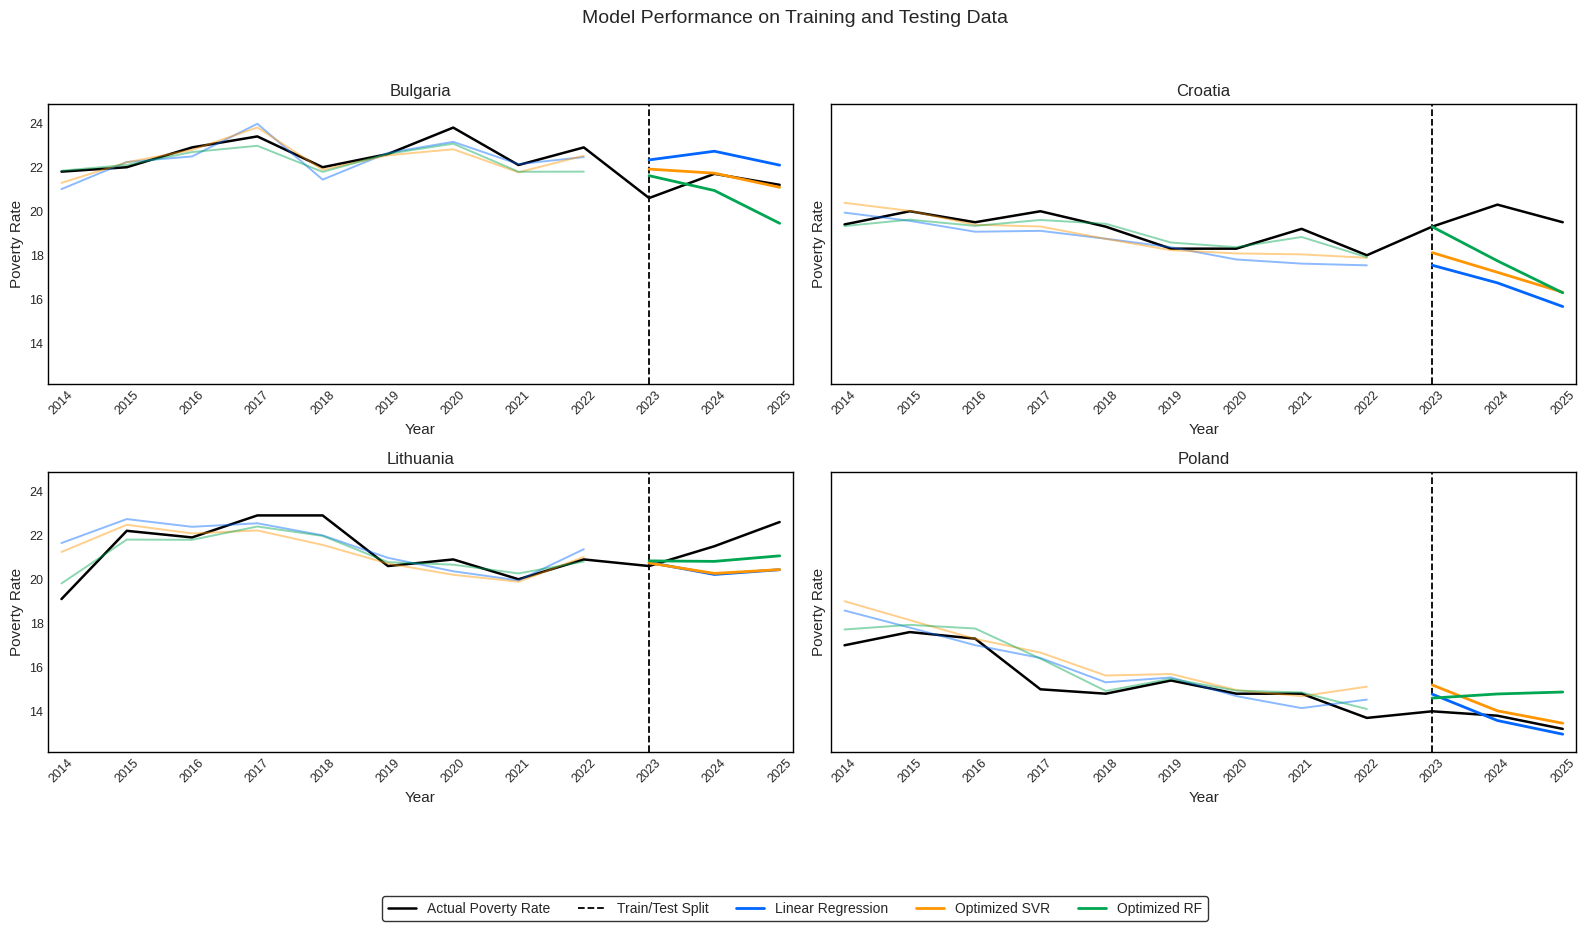

In [105]:
# Model performance on training vs testing data by country

# Training predictions
train_predictions_df = train_df[["Country", "Year", "Poverty"]].copy()

train_predictions_df["Linear Regression"] = lr_model.predict(X_train_scaled)
train_predictions_df["Optimized SVR"] = svr_search.best_estimator_.predict(X_train_scaled)
train_predictions_df["Optimized Random Forest"] = bayes_search.best_estimator_.predict(X_train)

# Testing predictions
test_predictions_df = test_df[["Country", "Year", "Poverty"]].copy()

test_predictions_df["Linear Regression"] = pred_lr
test_predictions_df["Optimized SVR"] = pred_svr_optimized
test_predictions_df["Optimized Random Forest"] = pred_rf_optimized

countries = df_sorted["Country"].unique()

model_colors = {
    "Linear Regression": "#0066FF",
    "Optimized SVR": "#FF9500",
    "Optimized RF": "#00A651"
}

# Standardized y-axis across all countries
y_min = df_sorted["Poverty"].min()
y_max = df_sorted["Poverty"].max()
y_padding = (y_max - y_min) * 0.10

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 9),
    sharex=False,
    sharey=True
)

axes = axes.flatten()

for ax, country in zip(axes, countries):

    full_country = df_sorted[
        df_sorted["Country"] == country
    ].sort_values("Year")

    train_country = train_predictions_df[
        train_predictions_df["Country"] == country
    ].sort_values("Year")

    test_country = test_predictions_df[
        test_predictions_df["Country"] == country
    ].sort_values("Year")

    # Actual poverty rate
    ax.plot(
        full_country["Year"],
        full_country["Poverty"],
        color="black",
        linewidth=1.8,
        label="Actual Poverty Rate"
    )

    # Train/test split line
    ax.axvline(
        x=2023,
        color="black",
        linestyle="--",
        linewidth=1.3,
        label="Train/Test Split"
    )

    # Linear Regression predictions: train + test
    ax.plot(
        train_country["Year"],
        train_country["Linear Regression"],
        color=model_colors["Linear Regression"],
        linewidth=1.4,
        alpha=0.45
    )

    ax.plot(
        test_country["Year"],
        test_country["Linear Regression"],
        color=model_colors["Linear Regression"],
        linewidth=2,
        label="Linear Regression"
    )

    # Optimized SVR predictions: train + test
    ax.plot(
        train_country["Year"],
        train_country["Optimized SVR"],
        color=model_colors["Optimized SVR"],
        linewidth=1.4,
        alpha=0.45
    )

    ax.plot(
        test_country["Year"],
        test_country["Optimized SVR"],
        color=model_colors["Optimized SVR"],
        linewidth=2,
        label="Optimized SVR"
    )

    # Optimized RF predictions: train + test
    ax.plot(
        train_country["Year"],
        train_country["Optimized Random Forest"],
        color=model_colors["Optimized RF"],
        linewidth=1.4,
        alpha=0.45
    )

    ax.plot(
        test_country["Year"],
        test_country["Optimized Random Forest"],
        color=model_colors["Optimized RF"],
        linewidth=2,
        label="Optimized RF"
    )

    ax.set_title(country, fontsize=12)
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Poverty Rate", fontsize=11)

    ax.set_xticks(range(2014, 2026))
    ax.tick_params(axis="x", labelsize=9, rotation=45)
    ax.tick_params(axis="y", labelsize=9)

    ax.set_xlim(2013.8, 2025.2)
    ax.set_ylim(y_min - y_padding, y_max + y_padding)

    ax.set_facecolor("white")
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)

# Shared legend
handles, labels = [], []

for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

unique = dict(zip(labels, handles))

fig.legend(
    unique.values(),
    unique.keys(),
    loc="lower center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=5,
    frameon=True,
    edgecolor="black",
    fontsize=10
)

plt.suptitle(
    "Model Performance on Training and Testing Data",
    fontsize=14
)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "model_performance_train_vs_test.png"
    ),
    dpi=400,
    bbox_inches="tight"
)

plt.show()

## Comparative Interpretation of Model Performance

Among the evaluated models, Support Vector Regression achieved the strongest overall predictive performance, obtaining the highest explained variance and the lowest prediction errors. The results suggest that poverty dynamics in the selected Eastern European countries are characterized by non-linear relationships that are not fully captured by traditional linear models.

Although Bayesian optimization slightly improved the Random Forest model, the performance gains remained modest, indicating that the baseline Random Forest configuration already captured the principal structural relationships within the dataset effectively.

## Euro Adoption Analysis

The following section examines socio-economic trends before and after euro adoption in Lithuania and Croatia. The objective is to explore whether the transition into the Eurozone coincided with observable changes in poverty, unemployment, inflation, and inequality indicators.

In [106]:
# Create PostAdoption variable

df["PostAdoption"] = 0

# Lithuania adopted euro in 2015

df.loc[
    (df["Country"] == "Lithuania") &
    (df["Year"] >= 2015),
    "PostAdoption"
] = 1

# Croatia adopted euro in 2023

df.loc[
    (df["Country"] == "Croatia") &
    (df["Year"] >= 2023),
    "PostAdoption"
] = 1


print("PostAdoption variable created successfully.")

PostAdoption variable created successfully.


## Pre- and Post-Adoption Comparison

The following analysis compares average socio-economic indicators before and after euro adoption in Lithuania and Croatia.

In [107]:
# Variables for comparison

variables = [
    "Poverty",
    "Inflation",
    "Unemployment",
    "Gini"
]

# Empty list

comparison_results = []

# Loop through variables

for variable in variables:

    for country in ["Lithuania", "Croatia"]:

        country_data = df[
            df["Country"] == country
        ]

        pre_mean = country_data[
            country_data["PostAdoption"] == 0
        ][variable].mean()

        post_mean = country_data[
            country_data["PostAdoption"] == 1
        ][variable].mean()

        comparison_results.append({
            "Country": country,
            "Variable": variable,
            "Pre_Adoption_Mean": round(pre_mean, 3),
            "Post_Adoption_Mean": round(post_mean, 3)
        })

# Create dataframe

comparison_table = pd.DataFrame(
    comparison_results
)

comparison_table

,Country,Variable,Pre_Adoption_Mean,Post_Adoption_Mean
0,Lithuania,Poverty,19.100,21.545
1,Croatia,Poverty,19.111,19.700
2,Lithuania,Inflation,0.200,4.182
3,Croatia,Inflation,1.822,5.600
4,Lithuania,Unemployment,10.700,7.191
5,Croatia,Unemployment,10.467,5.333
6,Lithuania,Gini,35.000,36.182
7,Croatia,Gini,29.467,29.333


## Interpretation of Pre- and Post-Adoption Trends

The descriptive comparison suggests that euro adoption did not produce uniform socio-economic outcomes across countries. In Lithuania, average poverty and inflation levels increased after euro adoption, while unemployment declined substantially. Croatia also experienced lower unemployment following euro adoption, although inflation increased noticeably during the post-adoption period.

The results suggest that monetary integration alone is insufficient to explain poverty dynamics, which remain strongly connected to structural socio-economic conditions.

## Statistical Comparison of Pre- and Post-Adoption Periods

To complement the descriptive comparison, an independent statistical comparison is conducted between the pre- and post-adoption periods for Lithuania and Croatia. The objective is to examine whether the observed changes in socio-economic indicators are statistically meaningful.

## T-Test Analysis

Independent t-test is performed for poverty, inflation, unemployment, and inequality indicators before and after euro adoption.

In [108]:
# Variables for statistical testing

variables = [
    "Poverty",
    "Inflation",
    "Unemployment",
    "Gini"
]

# Empty list for results

ttest_results = []

# Croatia only
# Lithuania excluded because only one pre-adoption observation exists

country_data = df[
    df["Country"] == "Croatia"
]

for variable in variables:

    pre_values = country_data[
        country_data["PostAdoption"] == 0
    ][variable]

    post_values = country_data[
        country_data["PostAdoption"] == 1
    ][variable]

    # Run t-test

    t_stat, p_value = ttest_ind(
        pre_values,
        post_values,
        equal_var=False
    )

    ttest_results.append({
        "Country": "Croatia",
        "Variable": variable,
        "T-Statistic": round(t_stat, 3),
        "P-Value": round(p_value, 4)
    })

# Create dataframe

ttest_table = pd.DataFrame(
    ttest_results
)

ttest_table

,Country,Variable,T-Statistic,P-Value
0,Croatia,Poverty,-1.498,0.1950
1,Croatia,Inflation,-2.072,0.0921
2,Croatia,Unemployment,3.577,0.0059
3,Croatia,Gini,0.276,0.7980


## Interpretation of Statistical Comparison

The statistical comparison was conducted for Croatia because the dataset contains sufficient observations both before and after euro adoption. Lithuania was excluded from inferential testing because only one pre-adoption observation (2014) is available, limiting the reliability of statistical inference.

The results indicate a statistically significant decrease in unemployment following euro adoption in Croatia (p < 0.01). Inflation increased during the post-adoption period, although the difference did not reach conventional significance thresholds. No statistically significant differences were identified for poverty or inequality indicators.

# Preliminary Findings

The empirical analysis suggests that poverty dynamics in the selected Eastern European countries are strongly associated with structural socio-economic conditions, particularly inequality, financial vulnerability, and unemployment levels.

The correlation analysis and SHAP interpretation consistently identified the Gini coefficient and the inability to cover unexpected expenses as among the most influential predictors of poverty rates. These findings indicate that broader structural inequalities and household-level economic insecurity play a central role in shaping poverty outcomes.

Among the evaluated machine learning approaches, Support Vector Regression achieved the strongest predictive performance, suggesting that poverty dynamics are characterized by non-linear relationships that are not fully captured by traditional linear models. Although Random Forest Regression also demonstrated strong predictive accuracy, Bayesian hyperparameter optimization produced only modest performance improvements, indicating that the baseline Random Forest configuration already captured much of the underlying structure within the dataset.

The euro adoption analysis revealed mixed socio-economic outcomes. Croatia experienced a statistically significant decline in unemployment following euro adoption, while inflation increased during the post-adoption period. However, no statistically significant changes were identified for poverty or inequality indicators. Lithuania displayed similar descriptive trends, although inferential statistical testing was limited by the small number of pre-adoption observations.

Overall, the findings suggest that euro adoption alone does not determine poverty trajectories. Instead, poverty outcomes appear to remain closely connected to deeper structural socio-economic conditions, including inequality, labor market dynamics, and household financial resilience.

# Conclusion

This notebook presented a machine learning and socio-economic analysis of poverty dynamics in selected Eastern European countries between 2014 and 2025. By combining exploratory analysis, predictive modeling, explainable artificial intelligence techniques, and comparative euro adoption analysis, the study examined both the determinants of poverty and the broader socio-economic implications of monetary integration.

The results demonstrated that non-linear machine learning models outperform traditional linear approaches in predicting poverty outcomes, highlighting the complexity of socio-economic relationships within the dataset. At the same time, the analysis emphasized that euro adoption does not produce uniform socio-economic effects across countries and indicators.

Several limitations should be acknowledged. The dataset contains a relatively small number of observations, particularly for post-adoption periods in Croatia and pre-adoption periods in Lithuania. Consequently, the findings should be interpreted cautiously and understood primarily as exploratory rather than strictly causal.

Future research could expand the dataset to include additional European countries, longer temporal horizons, and broader socio-economic indicators in order to strengthen both predictive performance and causal inference regarding euro adoption and poverty dynamics.

In [109]:
# Verify saved figure files

expected_figures = [
    "correlation_matrix.png",
    "poverty_trends_by_country.png",
    "linear_regression_coefficients.png",
    "rf_train_test_split.png",
    "shap_summary_violin.png"
]

for figure in expected_figures:
    path = os.path.join(FIGURE_DIR, figure)
    print(figure, "SAVED" if os.path.exists(path) else "MISSING")

print("\nSaved figures folder:", FIGURE_DIR)
print(os.listdir(FIGURE_DIR))


correlation_matrix.png SAVED
poverty_trends_by_country.png SAVED
linear_regression_coefficients.png SAVED
rf_train_test_split.png MISSING
shap_summary_violin.png MISSING

Saved figures folder: /content/figures
['correlation_matrix.png', '.ipynb_checkpoints', 'model_performance_train_vs_test.png', 'poverty_trends_by_country.png', 'linear_regression_coefficients.png', 'all_variables_evolution_by_country.png', 'shap_summary_beeswarm.png', 'country_level_forecasting_performance_final.png']
